<a href="https://colab.research.google.com/github/Santiago-Soria/proyecto-transformacion-texto-imagen/blob/main/notebooks/2_run_experimentos_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Santiago-Soria/proyecto-transformacion-texto-imagen.git
# ==========================================
# CELDA 1: Setup
# ==========================================
import sys, os

PROJECT_ROOT = '/content/proyecto-transformacion-texto-imagen'
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

!pip install -q transformers torch scikit-learn polars joblib

from transformers import logging as hf_logging
import warnings
hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore")

print("✓ Entorno listo")


Cloning into 'proyecto-transformacion-texto-imagen'...
remote: Enumerating objects: 335, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 335 (delta 20), reused 7 (delta 2), pack-reused 296 (from 1)
Receiving objects: 100% (335/335), 6.51 MiB | 13.46 MiB/s, done.
Resolving deltas: 100% (170/170), done.
✓ Entorno listo


In [2]:
# ==========================================
# CELDA 2: Carga de datos con los 3 splits
# ==========================================
import polars as pl
import numpy as np

ruta = f'{PROJECT_ROOT}/data/processed'

train_df = pl.read_csv(f'{ruta}/train.csv')
val_df   = pl.read_csv(f'{ruta}/validation.csv')
test_df  = pl.read_csv(f'{ruta}/test.csv')

X_train = train_df.get_column('text').to_list()
y_train = train_df.get_column('manual_classification').to_numpy()

X_val   = val_df.get_column('text').to_list()
y_val   = val_df.get_column('manual_classification').to_numpy()

X_test  = test_df.get_column('text').to_list()
y_test  = test_df.get_column('manual_classification').to_numpy()

print(f"✓ Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"  Train → Dep: {y_train.sum()} | No Dep: {(y_train==0).sum()}")
print(f"  Val   → Dep: {y_val.sum()}   | No Dep: {(y_val==0).sum()}")
print(f"  Test  → Dep: {y_test.sum()}  | No Dep: {(y_test==0).sum()}")


✓ Train: 908 | Val: 114 | Test: 114
  Train → Dep: 353 | No Dep: 555
  Val   → Dep: 44   | No Dep: 70
  Test  → Dep: 44  | No Dep: 70


In [3]:
# ==========================================
# CELDA 3: Funciones de utilidad corregidas
# ==========================================
from src.features.extraction import *
from src.models.train_classic import *
from src.models.train_transformer import *
from src.preprocessing_utils import *

print("✓ Funciones de utilidad cargadas")


✓ Funciones de utilidad cargadas


EXP 1.1: Limpieza Básica + TF-IDF + LogReg

Entrenando Regresión Logística para: Exp_1.1_TFIDF_LogReg

  Exp_1.1_TFIDF_LogReg
  Val  F1-Macro:  0.7137
  Test Accuracy:  0.7018
  Test Precision: 0.6867
  Test Recall:    0.6896
  Test F1-Macro:  0.6879  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.76      0.74      0.75        70
         Dep       0.61      0.64      0.62        44

    accuracy                           0.70       114
   macro avg       0.69      0.69      0.69       114
weighted avg       0.70      0.70      0.70       114


Confusion Matrix:


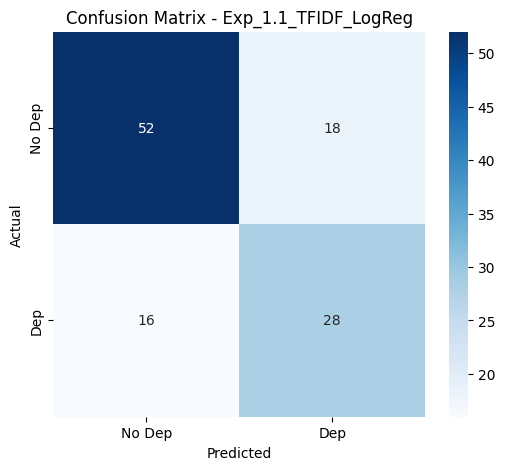

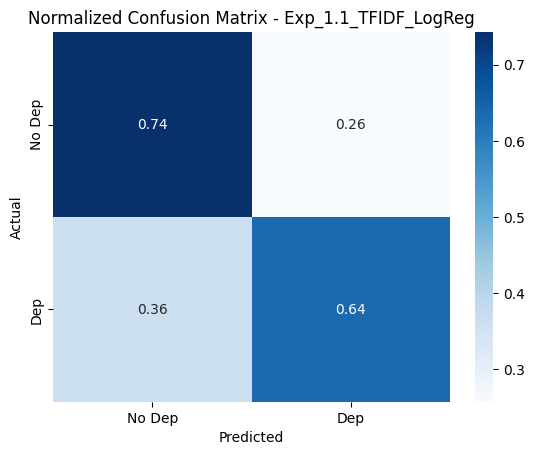


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_1.1_TFIDF_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_1.1_TFIDF_LogReg_metrics.json

EXP 1.2: Limpieza Básica + Stopwords + TF-IDF + LogReg

Entrenando Regresión Logística para: Exp_1.2_TFIDF_Stopwords_LogReg

  Exp_1.2_TFIDF_Stopwords_LogReg
  Val  F1-Macro:  0.6742
  Test Accuracy:  0.7105
  Test Precision: 0.6984
  Test Recall:    0.7052
  Test F1-Macro:  0.7004  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.78      0.73      0.76        70
         Dep       0.61      0.68      0.65        44

    accuracy                           0.71       114
   macro avg       0.70      0.71      0.70       114
weighted avg       0.72      0.71      0.71       114


Confusion Matrix:


<Figure size 640x480 with 0 Axes>

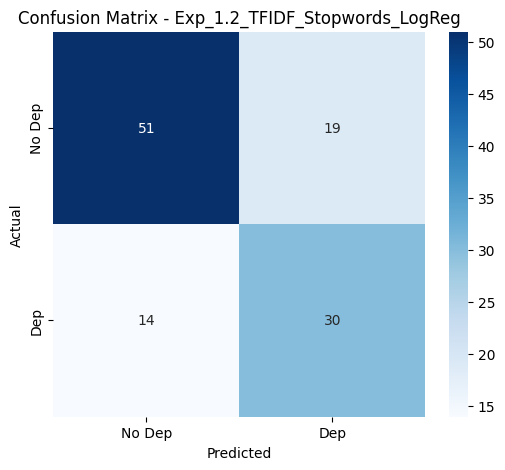

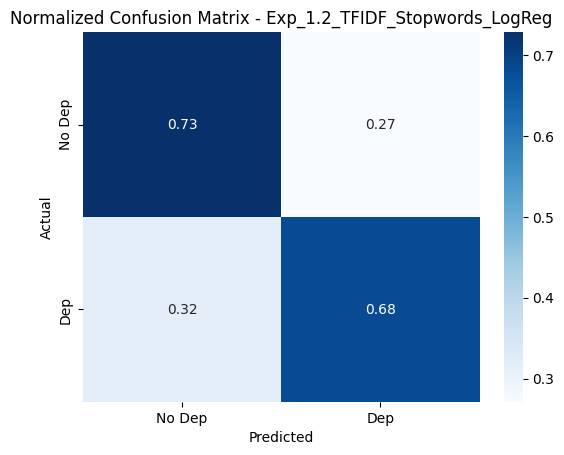


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_1.2_TFIDF_Stopwords_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_1.2_TFIDF_Stopwords_LogReg_metrics.json

✓ Experimentos 1.x completados


<Figure size 640x480 with 0 Axes>

In [4]:
# ==========================================
# CELDA 4: Experimentos 1.1 y 1.2 — TF-IDF
# ==========================================
import joblib
import os
extractor = FeatureExtractor()

# Define the models directory
models_dir = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(models_dir, exist_ok=True)

# ── Exp 1.1: Limpieza básica + TF-IDF ──────────────────────
print("EXP 1.1: Limpieza Básica + TF-IDF + LogReg")
X_train_clean = [preprocess_text(t, 'P1') for t in X_train]
X_val_clean   = [preprocess_text(t, 'P1') for t in X_val]
X_test_clean  = [preprocess_text(t, 'P1') for t in X_test]

X_tr_11, X_val_11, X_te_11, vec_11 = extractor.get_tfidf(
    X_train_clean, X_val_clean, X_test_clean)

_, _, metrics_11 = train_logistic(
    X_tr_11, y_train, X_val_11, y_val,
    X_te_11, y_test, 'Exp_1.1_TFIDF_LogReg', models_dir=models_dir)

# ── Exp 1.2: Limpieza básica + Stopwords + TF-IDF ──────────
print("\nEXP 1.2: Limpieza Básica + Stopwords + TF-IDF + LogReg")

X_train_sw = [preprocess_text(t, 'P2') for t in X_train]
X_val_sw   = [preprocess_text(t, 'P2') for t in X_val]
X_test_sw  = [preprocess_text(t, 'P2') for t in X_test]

X_tr_12, X_val_12, X_te_12, vec_12 = extractor.get_tfidf(
    X_train_sw, X_val_sw, X_test_sw)

_, _, metrics_12 = train_logistic(
    X_tr_12, y_train, X_val_12, y_val,
    X_te_12, y_test, 'Exp_1.2_TFIDF_Stopwords_LogReg', models_dir=models_dir)

print("\n✓ Experimentos 1.x completados")

EXP 2.1: BETO Frozen + LogReg
  Extrayendo embeddings (train)...
--> Extrayendo embeddings con dccuchile/bert-base-spanish-wwm-cased...


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

100%|██████████| 4/4 [00:01<00:00,  3.33it/s]


  Extrayendo embeddings (test)...
--> Extrayendo embeddings con dccuchile/bert-base-spanish-wwm-cased...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00,  4.90it/s]



Entrenando Regresión Logística para: Exp_2.1_BETO_Frozen_LogReg

  Exp_2.1_BETO_Frozen_LogReg
  Val  F1-Macro:  0.6038
  Test Accuracy:  0.7281
  Test Precision: 0.7147
  Test Recall:    0.7195
  Test F1-Macro:  0.7165  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.79      0.76      0.77        70
         Dep       0.64      0.68      0.66        44

    accuracy                           0.73       114
   macro avg       0.71      0.72      0.72       114
weighted avg       0.73      0.73      0.73       114


Confusion Matrix:


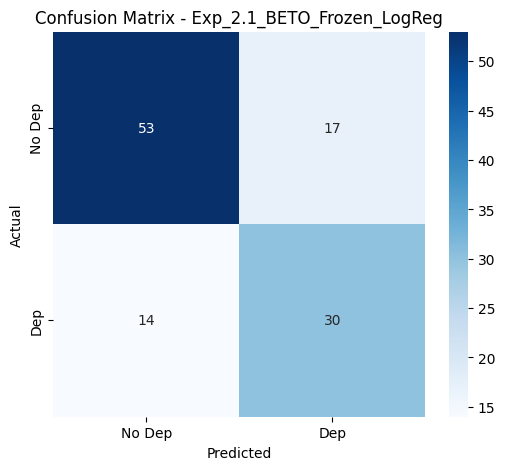

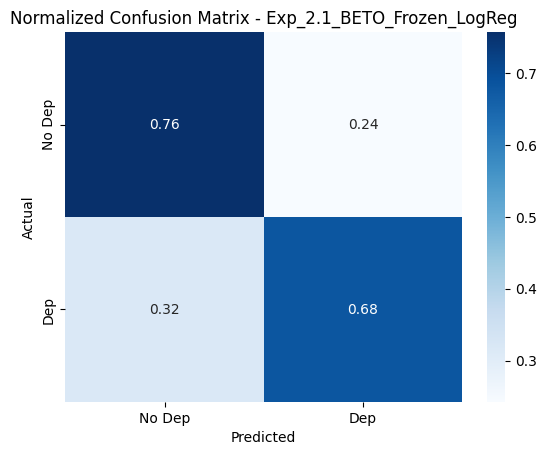


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_2.1_BETO_Frozen_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_2.1_BETO_Frozen_LogReg_metrics.json
EXP 2.2: RoBERTa Frozen + LogReg
  Extrayendo embeddings (train)...
--> Extrayendo embeddings con bertin-project/bertin-roberta-base-spanish...


config.json:   0%|          | 0.00/674 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  Extrayendo embeddings (test)...
--> Extrayendo embeddings con bertin-project/bertin-roberta-base-spanish...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00,  4.96it/s]



Entrenando Regresión Logística para: Exp_2.2_RoBERTa_Frozen_LogReg

  Exp_2.2_RoBERTa_Frozen_LogReg
  Val  F1-Macro:  0.6402
  Test Accuracy:  0.6228
  Test Precision: 0.6089
  Test Recall:    0.6127
  Test F1-Macro:  0.6096  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.71      0.66      0.68        70
         Dep       0.51      0.57      0.54        44

    accuracy                           0.62       114
   macro avg       0.61      0.61      0.61       114
weighted avg       0.63      0.62      0.63       114


Confusion Matrix:


<Figure size 640x480 with 0 Axes>

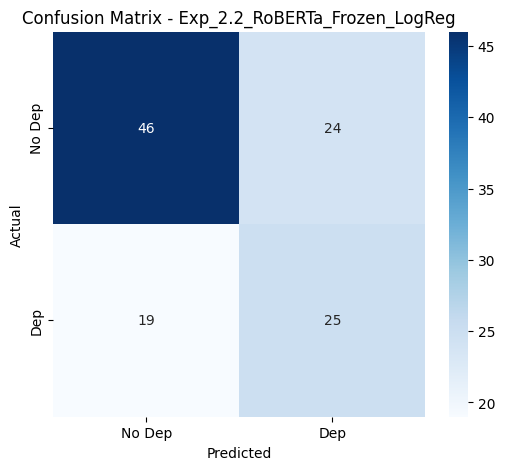

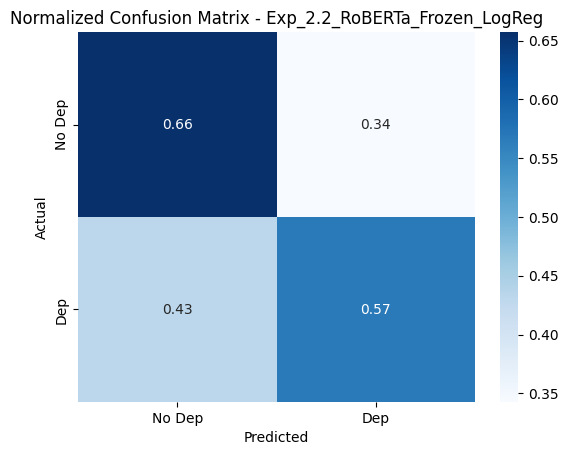


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_2.2_RoBERTa_Frozen_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_2.2_RoBERTa_Frozen_LogReg_metrics.json

EXP 2.3: mDeBERTa Frozen + LogReg
  Extrayendo embeddings (train)...
--> Extrayendo embeddings con microsoft/mdeberta-v3-base...


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

...

  Extrayendo embeddings (test)...
--> Extrayendo embeddings con microsoft/mdeberta-v3-base...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00,  7.13it/s]



Entrenando Regresión Logística para: Exp_2.3_mDeBERTa_Frozen_LogReg

  Exp_2.3_mDeBERTa_Frozen_LogReg
  Val  F1-Macro:  0.5885
  Test Accuracy:  0.5526
  Test Precision: 0.5262
  Test Recall:    0.5260
  Test F1-Macro:  0.5260  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.63      0.64      0.64        70
         Dep       0.42      0.41      0.41        44

    accuracy                           0.55       114
   macro avg       0.53      0.53      0.53       114
weighted avg       0.55      0.55      0.55       114


Confusion Matrix:


<Figure size 640x480 with 0 Axes>

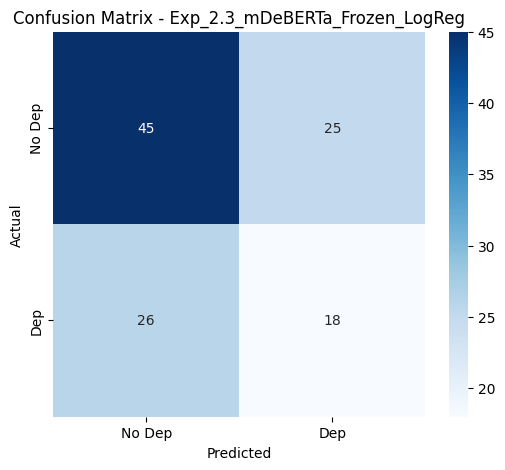

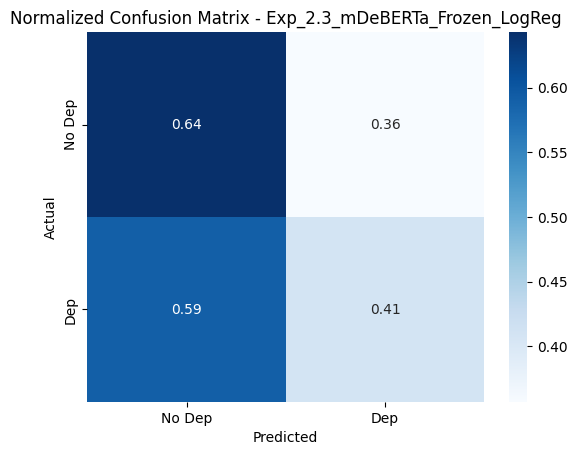


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_2.3_mDeBERTa_Frozen_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_2.3_mDeBERTa_Frozen_LogReg_metrics.json

EXP 2.4: XLM-RoBERTa Frozen + LogReg
  Extrayendo embeddings (train)...
--> Extrayendo embeddings con xlm-roberta-base...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

  Extrayendo embeddings (test)...
--> Extrayendo embeddings con xlm-roberta-base...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00,  4.44it/s]



Entrenando Regresión Logística para: Exp_2.4_XLM_Frozen_LogReg

  Exp_2.4_XLM_Frozen_LogReg
  Val  F1-Macro:  0.6923
  Test Accuracy:  0.6842
  Test Precision: 0.6685
  Test Recall:    0.6711
  Test F1-Macro:  0.6696  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.75      0.73      0.74        70
         Dep       0.59      0.61      0.60        44

    accuracy                           0.68       114
   macro avg       0.67      0.67      0.67       114
weighted avg       0.69      0.68      0.69       114


Confusion Matrix:


<Figure size 640x480 with 0 Axes>

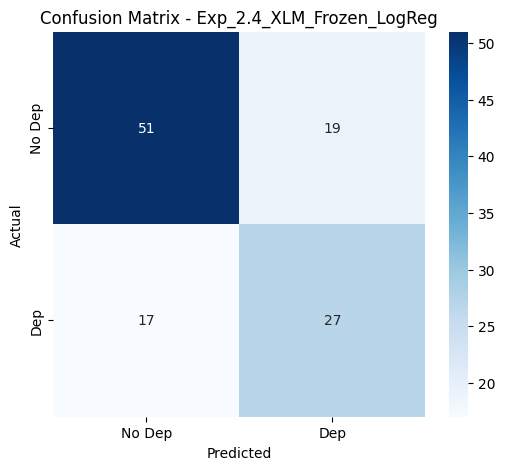

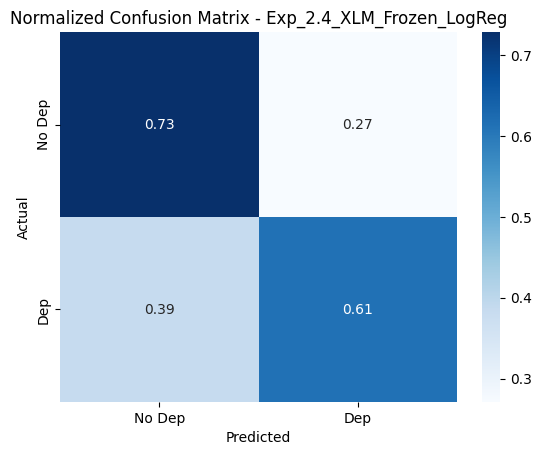


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_2.4_XLM_Frozen_LogReg.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_2.4_XLM_Frozen_LogReg_metrics.json

✓ Experimentos 2.x completados


<Figure size 640x480 with 0 Axes>

In [5]:
# ===============================================
# CELDA 5: Experimentos 2.1, 2.2, 2.3 y 2.4 — Frozen
# ===============================================

# ── Exp 2.1: RoBERTa Frozen ────────────────────────────────
print("EXP 2.1: BETO Frozen + LogReg")
BETO = "dccuchile/bert-base-spanish-wwm-cased"

print("  Extrayendo embeddings (train)...")
X_tr_21  = extractor.get_frozen_embeddings(X_train_clean, BETO)
print("  Extrayendo embeddings (val)...")
X_val_21 = extractor.get_frozen_embeddings(X_val_clean,   BETO)
print("  Extrayendo embeddings (test)...")
X_te_21  = extractor.get_frozen_embeddings(X_test_clean,  BETO)

_, _, metrics_21 = train_logistic(
    X_tr_21, y_train, X_val_21, y_val,
    X_te_21, y_test, 'Exp_2.1_BETO_Frozen_LogReg', models_dir=models_dir)

# ── Exp 2.2: RoBERTa Frozen ────────────────────────────────
print("EXP 2.2: RoBERTa Frozen + LogReg")
ROBERTA = 'bertin-project/bertin-roberta-base-spanish'

print("  Extrayendo embeddings (train)...")
X_tr_22  = extractor.get_frozen_embeddings(X_train_clean, ROBERTA)
print("  Extrayendo embeddings (val)...")
X_val_22 = extractor.get_frozen_embeddings(X_val_clean,   ROBERTA)
print("  Extrayendo embeddings (test)...")
X_te_22  = extractor.get_frozen_embeddings(X_test_clean,  ROBERTA)

_, _, metrics_22 = train_logistic(
    X_tr_22, y_train, X_val_22, y_val,
    X_te_22, y_test, 'Exp_2.2_RoBERTa_Frozen_LogReg', models_dir=models_dir)

# ── Exp 2.3: mDeBERTa Frozen ───────────────────────────────
print("\nEXP 2.3: mDeBERTa Frozen + LogReg")
MDEBERTA = 'microsoft/mdeberta-v3-base'

print("  Extrayendo embeddings (train)...")
X_tr_23  = extractor.get_frozen_embeddings(X_train_clean, MDEBERTA)
print("  Extrayendo embeddings (val)...")
X_val_23 = extractor.get_frozen_embeddings(X_val_clean,   MDEBERTA)
print("  Extrayendo embeddings (test)...")
X_te_23  = extractor.get_frozen_embeddings(X_test_clean,  MDEBERTA)

_, _, metrics_23 = train_logistic(
    X_tr_23, y_train, X_val_23, y_val,
    X_te_23, y_test, 'Exp_2.3_mDeBERTa_Frozen_LogReg', models_dir=models_dir)

# ── Exp 2.4: XLM-RoBERTa Frozen ───────────────────────────────
print("\nEXP 2.4: XLM-RoBERTa Frozen + LogReg")
XLM = "xlm-roberta-base"

print("  Extrayendo embeddings (train)...")
X_tr_24  = extractor.get_frozen_embeddings(X_train_clean, XLM)
print("  Extrayendo embeddings (val)...")
X_val_24 = extractor.get_frozen_embeddings(X_val_clean,   XLM)
print("  Extrayendo embeddings (test)...")
X_te_24  = extractor.get_frozen_embeddings(X_test_clean,  XLM)

_, _, metrics_24 = train_logistic(
    X_tr_24, y_train, X_val_24, y_val,
    X_te_24, y_test, 'Exp_2.4_XLM_Frozen_LogReg', models_dir=models_dir)


print("\n✓ Experimentos 2.x completados")


In [6]:
import os
import json
import torch
import numpy as np
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed
)
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Reproducibilidad
# ==============================
set_seed(42)


# ==============================
# Dataset
# ==============================
class DepressionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=128,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }


# ==============================
# Métricas
# ==============================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1,
    }


# ==============================
# Fine-Tuning Principal
# ==============================
def run_finetuning(train_texts, train_labels, val_texts, val_labels, model_name, models_dir):

    model_path = os.path.join(models_dir, f"{model_name}.pkl")
    results_dir = os.path.join(models_dir, "..", "results")
    os.makedirs(results_dir, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=2
    )

    train_ds = DepressionDataset(train_texts, train_labels, tokenizer)
    val_ds = DepressionDataset(val_texts, val_labels, tokenizer)

    safe_model_name = model_name.replace("/", "_")
    output_dir = f"models/checkpoints/{safe_model_name}"

    training_args = TrainingArguments(
        output_dir=output_dir,

        # Estrategia de evaluación
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",

        # Optimización
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=6,
        weight_decay=0.01,

        # Selección del mejor modelo
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,

        # Control de checkpoints
        save_total_limit=1,

        # Reproducibilidad
        seed=42,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()

    # ==========================
    # Evaluación Final
    # ==========================
    final_metrics = trainer.evaluate()
    print("\nFinal Evaluation Metrics:")
    print(final_metrics)

    # Guardar métricas en JSON
    os.makedirs("results", exist_ok=True)
    with open(f"results/{safe_model_name}_metrics.json", "w") as f:
        json.dump(final_metrics, f, indent=4)

    return trainer

In [7]:
def extraer_embeddings_finetuned(texts, ckpt_path, batch_size=16):
    """
    Extrae embeddings [CLS] del BETO fine-tuneado.
    Usa AutoModel (sin cabeza de clasificación) para obtener representaciones puras.
    """
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(ckpt_path)

    # AutoModel carga SOLO el encoder, sin la capa de clasificación
    model     = AutoModel.from_pretrained(ckpt_path).to(device)
    model.eval()

    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Extrayendo embeddings"):
        batch  = texts[i:i + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs    = model(**inputs)
            cls_emb    = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(cls_emb)

    return np.vstack(all_embeddings)


In [8]:
# ==========================================
# CELDA 6: Experimentos 3.1, 3.2, 3.3 y 3.4 — Fine-tuning
# ==========================================

# ── Exp 3.1: BETO Fine-Tuning ───────────────────────────
print("="*55)
print("EXP 3.1: BETO Fine-Tuning + Softmax")
print("  Train → val.csv (EarlyStopping) | Eval final → test.csv")
print("="*55)

trainer_31 = run_finetuning(
    X_train_clean, y_train,   # ← train para aprender pesos
    X_val_clean,   y_val,     # ← val para EarlyStopping (NO test)
    model_name=BETO,
    models_dir=models_dir
)


EXP 3.1: BETO Fine-Tuning + Softmax
  Train → val.csv (EarlyStopping) | Eval final → test.csv


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.6391', 'grad_norm': '11.44', 'learning_rate': '1.673e-05', 'epoch': '1'}
{'eval_loss': '0.5804', 'eval_accuracy': '0.6754', 'eval_precision_macro': '0.6557', 'eval_recall_macro': '0.6513', 'eval_f1_macro': '0.653', 'eval_runtime': '0.8579', 'eval_samples_per_second': '132.9', 'eval_steps_per_second': '9.325', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.5023', 'grad_norm': '18.45', 'learning_rate': '1.339e-05', 'epoch': '2'}
{'eval_loss': '0.6336', 'eval_accuracy': '0.6491', 'eval_precision_macro': '0.625', 'eval_recall_macro': '0.5877', 'eval_f1_macro': '0.5809', 'eval_runtime': '0.8795', 'eval_samples_per_second': '129.6', 'eval_steps_per_second': '9.096', 'epoch': '2'}


...

{'loss': '0.2464', 'grad_norm': '14.57', 'learning_rate': '6.725e-06', 'epoch': '4'}
{'eval_loss': '0.9121', 'eval_accuracy': '0.6404', 'eval_precision_macro': '0.6123', 'eval_recall_macro': '0.5763', 'eval_f1_macro': '0.5667', 'eval_runtime': '0.9014', 'eval_samples_per_second': '126.5', 'eval_steps_per_second': '8.875', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1189', 'grad_norm': '19.14', 'learning_rate': '3.392e-06', 'epoch': '5'}
{'eval_loss': '1.082', 'eval_accuracy': '0.6491', 'eval_precision_macro': '0.6239', 'eval_recall_macro': '0.613', 'eval_f1_macro': '0.6149', 'eval_runtime': '0.9175', 'eval_samples_per_second': '124.2', 'eval_steps_per_second': '8.719', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '165.6', 'train_samples_per_second': '32.89', 'train_steps_per_second': '2.065', 'train_loss': '0.3754', 'epoch': '5'}
{'eval_loss': '0.6919', 'eval_accuracy': '0.693', 'eval_precision_macro': '0.683', 'eval_recall_macro': '0.6909', 'eval_f1_macro': '0.6842', 'eval_runtime': '0.969', 'eval_samples_per_second': '117.6', 'eval_steps_per_second': '8.256', 'epoch': '5'}

Final Evaluation Metrics:
{'eval_loss': 0.6919025778770447, 'eval_accuracy': 0.6929824561403509, 'eval_precision_macro': 0.6830065359477124, 'eval_recall_macro': 0.6909090909090909, 'eval_f1_macro': 0.6842105263157894, 'eval_runtime': 0.969, 'eval_samples_per_second': 117.645, 'eval_steps_per_second': 8.256, 'epoch': 5.0}


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 57/57 [00:08<00:00,  7.07it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:00<00:00,  8.96it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:00<00:00,  8.70it/s]



Entrenando Regresión Logística para: Exp_3.1_BETO_FineTuning

  Exp_3.1_BETO_FineTuning
  Val  F1-Macro:  0.6114
  Test Accuracy:  0.7544
  Test Precision: 0.7419
  Test Recall:    0.7325
  Test F1-Macro:  0.7361  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.78      0.83      0.81        70
         Dep       0.70      0.64      0.67        44

    accuracy                           0.75       114
   macro avg       0.74      0.73      0.74       114
weighted avg       0.75      0.75      0.75       114


Confusion Matrix:


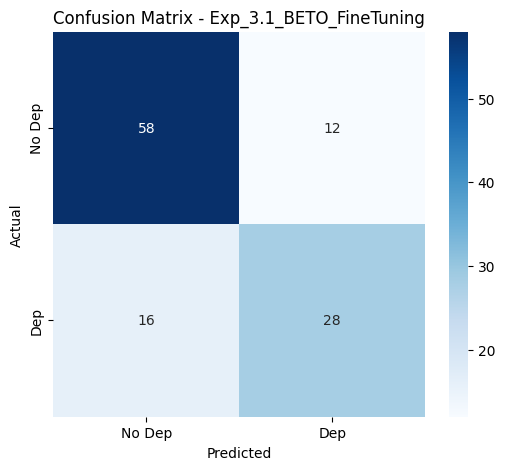

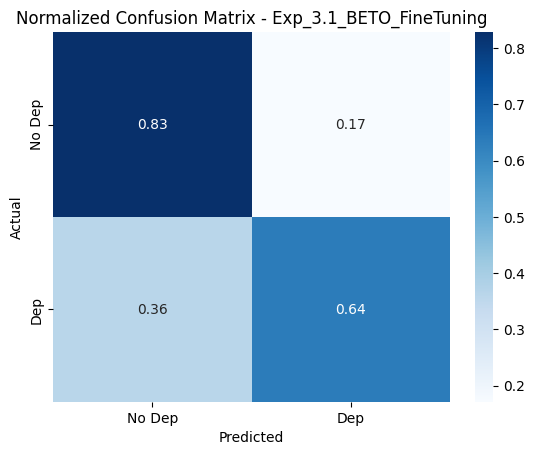


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_3.1_BETO_FineTuning.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_3.1_BETO_FineTuning_metrics.json


<Figure size 640x480 with 0 Axes>

In [9]:

# Extraer embeddings del modelo fine-tuneado para PKL
from transformers import AutoModelForSequenceClassification
CKPT_31 = f'{PROJECT_ROOT}/models/checkpoints/dccuchile_bert-base-spanish-wwm-cased/checkpoint-171'

# Guardar tokenizer en checkpoint
AutoTokenizer.from_pretrained(BETO).save_pretrained(CKPT_31)

X_tr_31  = extraer_embeddings_finetuned(X_train_clean, CKPT_31)
X_val_31 = extraer_embeddings_finetuned(X_val_clean,   CKPT_31)
X_te_31  = extraer_embeddings_finetuned(X_test_clean,  CKPT_31)

_, _, metrics_31 = train_logistic(
    X_tr_31, y_train, X_val_31, y_val,
    X_te_31, y_test, 'Exp_3.1_BETO_FineTuning', models_dir=models_dir)


In [10]:
# ── Exp 3.2: ROBERTA Fine-Tuning ───────────────────────────
print("="*55)
print("EXP 3.2: ROBERTA Fine-Tuning + Softmax")
print("  Train → val.csv (EarlyStopping) | Eval final → test.csv")
print("="*55)

trainer_32 = run_finetuning(
    X_train_clean, y_train,   # ← train para aprender pesos
    X_val_clean,   y_val,     # ← val para EarlyStopping (NO test)
    model_name=ROBERTA,
    models_dir=models_dir
)

EXP 3.2: ROBERTA Fine-Tuning + Softmax
  Train → val.csv (EarlyStopping) | Eval final → test.csv


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.6739', 'grad_norm': '3.786', 'learning_rate': '1.673e-05', 'epoch': '1'}
{'eval_loss': '0.6442', 'eval_accuracy': '0.6053', 'eval_precision_macro': '0.3053', 'eval_recall_macro': '0.4929', 'eval_f1_macro': '0.377', 'eval_runtime': '0.8862', 'eval_samples_per_second': '128.6', 'eval_steps_per_second': '9.027', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.593', 'grad_norm': '8.324', 'learning_rate': '1.339e-05', 'epoch': '2'}
{'eval_loss': '0.5905', 'eval_accuracy': '0.6404', 'eval_precision_macro': '0.6196', 'eval_recall_macro': '0.6185', 'eval_f1_macro': '0.619', 'eval_runtime': '0.8908', 'eval_samples_per_second': '128', 'eval_steps_per_second': '8.981', 'epoch': '2'}


...

{'loss': '0.1956', 'grad_norm': '20.22', 'learning_rate': '3.392e-06', 'epoch': '5'}
{'eval_loss': '0.8885', 'eval_accuracy': '0.6667', 'eval_precision_macro': '0.6579', 'eval_recall_macro': '0.6653', 'eval_f1_macro': '0.6581', 'eval_runtime': '0.928', 'eval_samples_per_second': '122.8', 'eval_steps_per_second': '8.621', 'epoch': '5'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1176', 'grad_norm': '2.374', 'learning_rate': '5.848e-08', 'epoch': '6'}
{'eval_loss': '0.9342', 'eval_accuracy': '0.6842', 'eval_precision_macro': '0.6787', 'eval_recall_macro': '0.688', 'eval_f1_macro': '0.6779', 'eval_runtime': '0.8979', 'eval_samples_per_second': '127', 'eval_steps_per_second': '8.91', 'epoch': '6'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '226.5', 'train_samples_per_second': '24.05', 'train_steps_per_second': '1.51', 'train_loss': '0.3934', 'epoch': '6'}
{'eval_loss': '0.6493', 'eval_accuracy': '0.7018', 'eval_precision_macro': '0.7038', 'eval_recall_macro': '0.7149', 'eval_f1_macro': '0.6984', 'eval_runtime': '0.9465', 'eval_samples_per_second': '120.4', 'eval_steps_per_second': '8.452', 'epoch': '6'}

Final Evaluation Metrics:
{'eval_loss': 0.649337112903595, 'eval_accuracy': 0.7017543859649122, 'eval_precision_macro': 0.7038177339901477, 'eval_recall_macro': 0.714935064935065, 'eval_f1_macro': 0.6984126984126984, 'eval_runtime': 0.9465, 'eval_samples_per_second': 120.445, 'eval_steps_per_second': 8.452, 'epoch': 6.0}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 57/57 [00:06<00:00,  8.31it/s]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:00<00:00,  9.21it/s]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:00<00:00,  9.16it/s]



Entrenando Regresión Logística para: Exp_3.2_RoBERTa_FineTuning

  Exp_3.2_RoBERTa_FineTuning
  Val  F1-Macro:  0.6941
  Test Accuracy:  0.6579
  Test Precision: 0.6401
  Test Recall:    0.6412
  Test F1-Macro:  0.6406  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.72      0.71      0.72        70
         Dep       0.56      0.57      0.56        44

    accuracy                           0.66       114
   macro avg       0.64      0.64      0.64       114
weighted avg       0.66      0.66      0.66       114


Confusion Matrix:


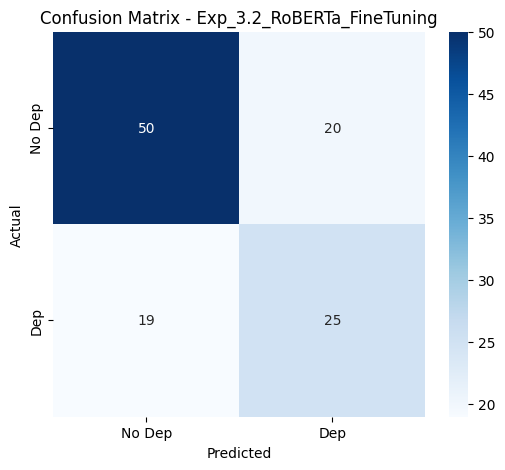

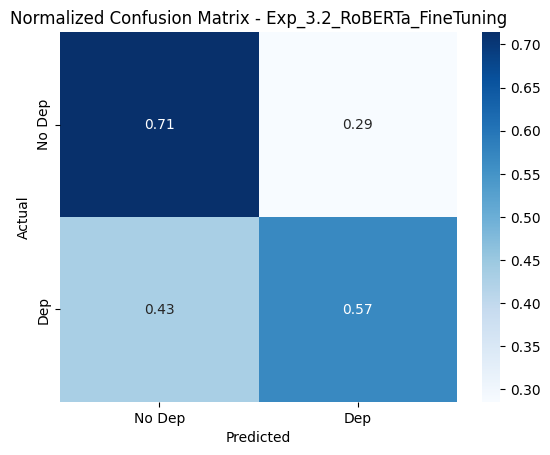


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_3.2_RoBERTa_FineTuning.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_3.2_RoBERTa_FineTuning_metrics.json


<Figure size 640x480 with 0 Axes>

In [11]:

# Extraer embeddings del modelo fine-tuneado para PKL
from transformers import AutoModelForSequenceClassification
CKPT_32 = f'{PROJECT_ROOT}/models/checkpoints/bertin-project_bertin-roberta-base-spanish/checkpoint-228'

# Guardar tokenizer en checkpoint
AutoTokenizer.from_pretrained(ROBERTA).save_pretrained(CKPT_32)

X_tr_32  = extraer_embeddings_finetuned(X_train_clean, CKPT_32)
X_val_32 = extraer_embeddings_finetuned(X_val_clean,   CKPT_32)
X_te_32  = extraer_embeddings_finetuned(X_test_clean,  CKPT_32)

_, _, metrics_32 = train_logistic(
    X_tr_32, y_train, X_val_32, y_val,
    X_te_32, y_test, 'Exp_3.2_RoBERTa_FineTuning', models_dir=models_dir)


In [12]:
# ── Exp 3.3: ROBERTA Fine-Tuning ───────────────────────────
print("="*55)
print("EXP 3.3: mDeBERTa Fine-Tuning + Softmax")
print("  Train → val.csv (EarlyStopping) | Eval final → test.csv")
print("="*55)

trainer_33 = run_finetuning(
    X_train_clean, y_train,   # ← train para aprender pesos
    X_val_clean,   y_val,     # ← val para EarlyStopping (NO test)
    model_name=MDEBERTA,
    models_dir=models_dir
)

EXP 3.3: mDeBERTa Fine-Tuning + Softmax
  Train → val.csv (EarlyStopping) | Eval final → test.csv


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

{'loss': '0.7542', 'grad_norm': 'nan', 'learning_rate': '1.673e-05', 'epoch': '1'}
{'eval_loss': 'nan', 'eval_accuracy': '0.614', 'eval_precision_macro': '0.307', 'eval_recall_macro': '0.5', 'eval_f1_macro': '0.3804', 'eval_runtime': '0.4578', 'eval_samples_per_second': '249', 'eval_steps_per_second': '17.48', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0', 'grad_norm': 'nan', 'learning_rate': '1.339e-05', 'epoch': '2'}
{'eval_loss': 'nan', 'eval_accuracy': '0.614', 'eval_precision_macro': '0.307', 'eval_recall_macro': '0.5', 'eval_f1_macro': '0.3804', 'eval_runtime': '0.4586', 'eval_samples_per_second': '248.6', 'eval_steps_per_second': '17.45', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0', 'grad_norm': 'nan', 'learning_rate': '1.006e-05', 'epoch': '3'}
{'eval_loss': 'nan', 'eval_accuracy': '0.614', 'eval_precision_macro': '0.307', 'eval_recall_macro': '0.5', 'eval_f1_macro': '0.3804', 'eval_runtime': '0.4179', 'eval_samples_per_second': '272.8', 'eval_steps_per_second': '19.14', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '94.84', 'train_samples_per_second': '57.45', 'train_steps_per_second': '3.606', 'train_loss': '0.2514', 'epoch': '3'}
{'eval_loss': 'nan', 'eval_accuracy': '0.614', 'eval_precision_macro': '0.307', 'eval_recall_macro': '0.5', 'eval_f1_macro': '0.3804', 'eval_runtime': '0.5334', 'eval_samples_per_second': '213.7', 'eval_steps_per_second': '15', 'epoch': '3'}

Final Evaluation Metrics:
{'eval_loss': nan, 'eval_accuracy': 0.6140350877192983, 'eval_precision_macro': 0.30701754385964913, 'eval_recall_macro': 0.5, 'eval_f1_macro': 0.3804347826086957, 'eval_runtime': 0.5334, 'eval_samples_per_second': 213.716, 'eval_steps_per_second': 14.998, 'epoch': 3.0}


In [14]:

# Extraer embeddings del modelo fine-tuneado para PKL
from transformers import AutoModelForSequenceClassification
CKPT_33 = f'{PROJECT_ROOT}/models/checkpoints/microsoft_mdeberta-v3-base/checkpoint-57'

# Guardar tokenizer en checkpoint
AutoTokenizer.from_pretrained(MDEBERTA).save_pretrained(CKPT_33)

X_tr_33  = extraer_embeddings_finetuned(X_train_clean, CKPT_33)
X_val_33 = extraer_embeddings_finetuned(X_val_clean,   CKPT_33)
X_te_33  = extraer_embeddings_finetuned(X_test_clean,  CKPT_33)

_, _, metrics_33 = train_logistic(
    X_tr_33, y_train, X_val_33, y_val,
    X_te_33, y_test, 'Exp_3.3_mDeBERTa_FineTuning', models_dir=models_dir)


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 57/57 [00:02<00:00, 19.36it/s]


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:00<00:00, 15.64it/s]


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:00<00:00, 12.15it/s]



Entrenando Regresión Logística para: Exp_3.3_mDeBERTa_FineTuning


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [15]:
# ── Exp 3.4: XLM Fine-Tuning ───────────────────────────
print("="*55)
print("EXP 3.4: XLM Fine-Tuning + Softmax")
print("  Train → val.csv (EarlyStopping) | Eval final → test.csv")
print("="*55)

trainer_34 = run_finetuning(
    X_train_clean, y_train,   # ← train para aprender pesos
    X_val_clean,   y_val,     # ← val para EarlyStopping (NO test)
    model_name=XLM,
    models_dir=models_dir
)

EXP 3.4: XLM Fine-Tuning + Softmax
  Train → val.csv (EarlyStopping) | Eval final → test.csv


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

{'loss': '0.6878', 'grad_norm': '2.024', 'learning_rate': '1.673e-05', 'epoch': '1'}
{'eval_loss': '0.6892', 'eval_accuracy': '0.614', 'eval_precision_macro': '0.307', 'eval_recall_macro': '0.5', 'eval_f1_macro': '0.3804', 'eval_runtime': '0.8472', 'eval_samples_per_second': '134.6', 'eval_steps_per_second': '9.443', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6767', 'grad_norm': '3.031', 'learning_rate': '1.339e-05', 'epoch': '2'}
{'eval_loss': '0.6654', 'eval_accuracy': '0.614', 'eval_precision_macro': '0.307', 'eval_recall_macro': '0.5', 'eval_f1_macro': '0.3804', 'eval_runtime': '0.891', 'eval_samples_per_second': '127.9', 'eval_steps_per_second': '8.979', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.6578', 'grad_norm': '6.42', 'learning_rate': '1.006e-05', 'epoch': '3'}
{'eval_loss': '0.657', 'eval_accuracy': '0.614', 'eval_precision_macro': '0.307', 'eval_recall_macro': '0.5', 'eval_f1_macro': '0.3804', 'eval_runtime': '0.8543', 'eval_samples_per_second': '133.4', 'eval_steps_per_second': '9.364', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '358.6', 'train_samples_per_second': '15.19', 'train_steps_per_second': '0.954', 'train_loss': '0.6741', 'epoch': '3'}
{'eval_loss': '0.689', 'eval_accuracy': '0.614', 'eval_precision_macro': '0.307', 'eval_recall_macro': '0.5', 'eval_f1_macro': '0.3804', 'eval_runtime': '0.8885', 'eval_samples_per_second': '128.3', 'eval_steps_per_second': '9.004', 'epoch': '3'}

Final Evaluation Metrics:
{'eval_loss': 0.6889529824256897, 'eval_accuracy': 0.6140350877192983, 'eval_precision_macro': 0.30701754385964913, 'eval_recall_macro': 0.5, 'eval_f1_macro': 0.3804347826086957, 'eval_runtime': 0.8885, 'eval_samples_per_second': 128.31, 'eval_steps_per_second': 9.004, 'epoch': 3.0}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 57/57 [00:06<00:00,  8.56it/s]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:00<00:00,  8.55it/s]


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Extrayendo embeddings: 100%|██████████| 8/8 [00:01<00:00,  7.53it/s]



Entrenando Regresión Logística para: Exp_3.4_XLM_FineTuning

  Exp_3.4_XLM_FineTuning
  Val  F1-Macro:  0.6173
  Test Accuracy:  0.5526
  Test Precision: 0.5262
  Test Recall:    0.5260
  Test F1-Macro:  0.5260  ← métrica principal

              precision    recall  f1-score   support

      No Dep       0.63      0.64      0.64        70
         Dep       0.42      0.41      0.41        44

    accuracy                           0.55       114
   macro avg       0.53      0.53      0.53       114
weighted avg       0.55      0.55      0.55       114


Confusion Matrix:


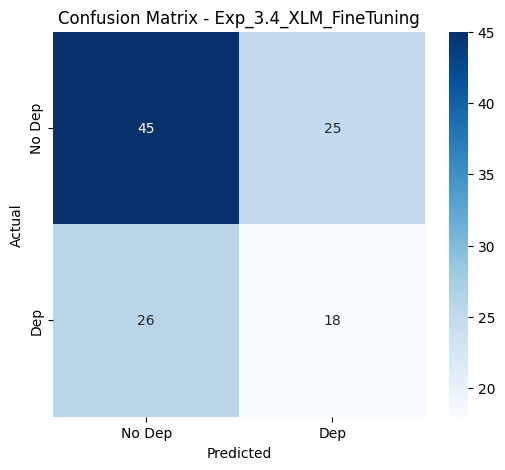

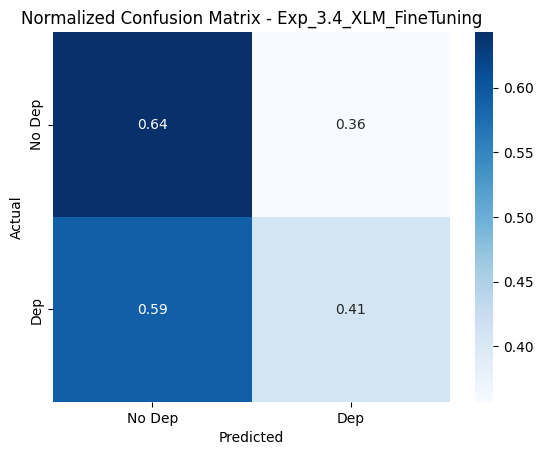


Modelo guardado en: /content/proyecto-transformacion-texto-imagen/models/Exp_3.4_XLM_FineTuning.pkl
Métricas guardadas en: /content/proyecto-transformacion-texto-imagen/models/../results/Exp_3.4_XLM_FineTuning_metrics.json


<Figure size 640x480 with 0 Axes>

In [16]:

# Extraer embeddings del modelo fine-tuneado para PKL
from transformers import AutoModelForSequenceClassification
CKPT_34 = f'{PROJECT_ROOT}/models/checkpoints/xlm-roberta-base/checkpoint-57'

# Guardar tokenizer en checkpoint
AutoTokenizer.from_pretrained(XLM).save_pretrained(CKPT_34)

X_tr_34  = extraer_embeddings_finetuned(X_train_clean, CKPT_34)
X_val_34 = extraer_embeddings_finetuned(X_val_clean,   CKPT_34)
X_te_34  = extraer_embeddings_finetuned(X_test_clean,  CKPT_34)

_, _, metrics_34 = train_logistic(
    X_tr_34, y_train, X_val_34, y_val,
    X_te_34, y_test, 'Exp_3.4_XLM_FineTuning', models_dir=models_dir)


In [17]:
# ==========================================
# CELDA 7: Tabla comparativa final
# ==========================================
import json
RESULTS_DIR = f'{PROJECT_ROOT}/results'

# Recolectar todas las métricas
todos_metrics = [
    metrics_11, metrics_12,
    metrics_21, metrics_22,
    metrics_23, metrics_23,
    metrics_31, metrics_32,
    metrics_34,
]

# Ordenar por F1 test descendente
todos_metrics.sort(key=lambda x: x['f1_macro_test'], reverse=True)

print("\n" + "="*80)
print("📊 TABLA COMPARATIVA FINAL — TODOS LOS EXPERIMENTOS")
print("="*80)
print(f"{'Experimento':<40} {'F1-Val':>8} {'F1-Test':>8} {'Accuracy':>9}")
print("-"*80)

for m in todos_metrics:
    marker = " ← BASELINE" if m == todos_metrics[0] else ""
    print(f"{m['experiment']:<40} "
          f"{m.get('f1_macro_val', 0):>8.4f} "
          f"{m['f1_macro_test']:>8.4f} "
          f"{m['accuracy_test']:>9.4f}{marker}")

# Guardar tabla completa
tabla_path = f'{RESULTS_DIR}/tabla_comparativa_final.json'
with open(tabla_path, 'w') as f:
    json.dump(todos_metrics, f, indent=4, ensure_ascii=False)

print(f"\n✓ Tabla guardada en {tabla_path}")
print(f"\n🏆 BASELINE SELECCIONADO: {todos_metrics[0]['experiment']}")
print(f"   F1-Macro Test: {todos_metrics[0]['f1_macro_test']:.4f}")



📊 TABLA COMPARATIVA FINAL — TODOS LOS EXPERIMENTOS
Experimento                                F1-Val  F1-Test  Accuracy
--------------------------------------------------------------------------------
Exp_3.1_BETO_FineTuning                    0.6114   0.7361    0.7544 ← BASELINE
Exp_2.1_BETO_Frozen_LogReg                 0.6038   0.7165    0.7281
Exp_1.2_TFIDF_Stopwords_LogReg             0.6742   0.7004    0.7105
Exp_1.1_TFIDF_LogReg                       0.7137   0.6879    0.7018
Exp_3.2_RoBERTa_FineTuning                 0.6941   0.6406    0.6579
Exp_2.2_RoBERTa_Frozen_LogReg              0.6402   0.6096    0.6228
Exp_2.3_mDeBERTa_Frozen_LogReg             0.5885   0.5260    0.5526
Exp_2.3_mDeBERTa_Frozen_LogReg             0.5885   0.5260    0.5526
Exp_3.4_XLM_FineTuning                     0.6173   0.5260    0.5526

✓ Tabla guardada en /content/proyecto-transformacion-texto-imagen/results/tabla_comparativa_final.json

🏆 BASELINE SELECCIONADO: Exp_3.1_BETO_FineTuning
   F1-Macro 

In [19]:
# ==========================================
# CELDA 8: Backup completo en Drive
# ==========================================
from google.colab import drive
import shutil

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/TT_Resultados/Experimentos_Final'
os.makedirs(DRIVE_DIR, exist_ok=True)

shutil.copytree(models_dir, f'{DRIVE_DIR}/models', dirs_exist_ok=True)
shutil.copytree(RESULTS_DIR, f'{DRIVE_DIR}/results', dirs_exist_ok=True)

print(f"✅ Backup completo en: {DRIVE_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Backup completo en: /content/drive/MyDrive/TT_Resultados/Experimentos_Final
